<a href="https://colab.research.google.com/github/Ayushman2005-cmyk/DMPM_EXPERIMENTS/blob/main/DMPM_LAB6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
df = pd.read_csv('Heart_Attack.csv')
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (1319, 9)


,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin,class
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("\nFeatures scaled successfully.")

Training set size: 923 samples
Testing set size: 396 samples

Features scaled successfully.


In [11]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
print("KNN model trained successfully with k=5.")

KNN model trained successfully with k=5.


Accuracy: 0.6465
Precision: 0.6551
Recall: 0.6465
F1-Score: 0.6495

Classification Report:
              precision    recall  f1-score   support

    negative       0.54      0.60      0.57       153
    positive       0.73      0.67      0.70       243

    accuracy                           0.65       396
   macro avg       0.63      0.64      0.63       396
weighted avg       0.66      0.65      0.65       396



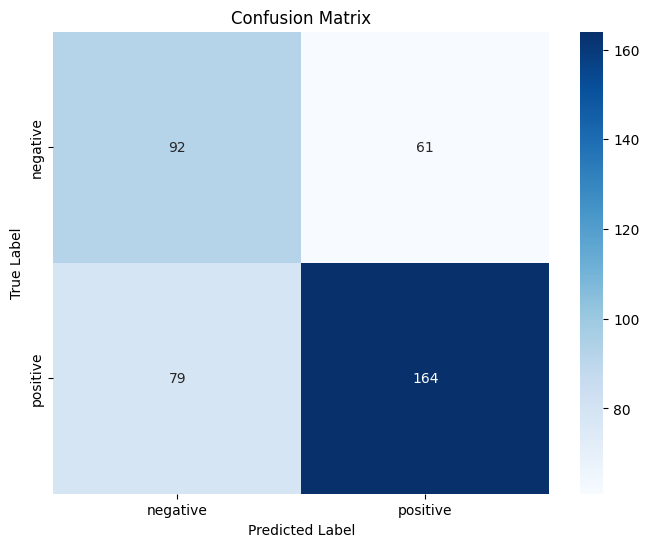

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
y_pred = knn.predict(X_test_scaled)
class_names = [str(label) for label in sorted(y.unique())]
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()